<a href="https://colab.research.google.com/github/ninobronw/BPALM-TOOL-IMPLEMENTATION/blob/main/HelmNet_Full_Codejla1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [3]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 12.0 MB/s eta 0:00:00


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [5]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [6]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.20.0


In [7]:
# 1. Set Python random seed
random.seed(812)

# 2. Set NumPy random seed
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops (if using GPU)
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import os

# List contents of MyDrive to find the correct folder name
print("Contents of /content/drive/MyDrive:")
print(os.listdir('/content/drive/MyDrive'))

# Correcting the path to include the trailing space based on os.listdir output
dataset_folder_path = '/content/drive/MyDrive/IHelmet Project '

try:
    print(f"\nListing contents of: {dataset_folder_path}")
    print(os.listdir(dataset_folder_path))
except FileNotFoundError:
    print(f"Error: The folder '{dataset_folder_path}' was not found. Please double-check the path in your Google Drive.")

Contents of /content/drive/MyDrive:
['IMG-1561.JPG', 'CV Dr ABENA_23_02_2018 GABON .doc', 'IMG_1496.JPG', 'Project Proposal Template.gdoc', 'Document 2.pdf', "LES NOYEURS D'EBEBDA.pdf", 'Clair.jpg', 'QR Linked.png', 'Untitled Diagram (1).html', 'Untitled Diagram.html', 'convertio.co', 'Document2.docx', 'Invitation à notre fête.gform', 'Comores 2019', 'SandBox', 'SCAN0013.PDF', 'SCAN0013.PDF.gdoc', 'Code électoral FCC.docx', 'Copie traduite de Index for TB Tools_Nigeria.gdoc', 'Document sans titre (189).gdoc', 'E books ', 'EBOOK Elaine N Aron - Ces gens qui ont peur d avoir peur.pdf', 'EBOOK Sebastien Fedeli - Aux voleurs.pdf', 'EBOOK Srdja Popovic Comment faire tomber un dictateur quand on est seul tout petit et sans armes -.pdf', 'Chase,James Hadley - Qui vivra, rira.pdf', 'SAS 188 - Rouge dragon T1 Gerard de Villiers.pdf', 'SAS 184 - Renegade T2 Gerard de Villiers.pdf', 'SAS 183 - Renegade T1 Gerard de Villiers.pdf', 'SAS 189 - Rouge dragon T2 Gerard de Villiers.pdf', 'SAS 185 - F

Now that we have confirmed the contents of the dataset folder, let's load the `labels.csv` file into a pandas DataFrame. This file likely contains the classification labels for your images.

In [10]:
import pandas as pd
import os

# The dataset_folder_path is defined in a previous cell and corrected to point to the Google Drive folder.
# We will use this to construct the correct path to labels.csv.
# Based on kernel state, dataset_folder_path is '/content/drive/MyDrive/IHelmet Project '

# Construct the full path to labels.csv within the dataset folder
labels_file_path = os.path.join(dataset_folder_path, 'labels.csv')

# Load the labels.csv file
try:
    labels_df = pd.read_csv(labels_file_path)
    print("Labels DataFrame loaded successfully. Here's a preview:")
    print(labels_df.head())
    print(f"\nShape of labels_df: {labels_df.shape}")
except FileNotFoundError:
    print(f"Error: labels.csv not found at {labels_file_path}. Please ensure the file is in the specified folder and the path is correct.")
except Exception as e:
    print(f"An error occurred while loading labels.csv: {e}")

Labels DataFrame loaded successfully. Here's a preview:
   label
0      0
1      0
2      0
3      0
4      0

Shape of labels_df: (4125, 1)


Before proceeding, let's examine the distribution of classes in our `labels_df` to check for any class imbalance. This is important as imbalanced datasets can lead to models that perform well on the majority class but poorly on the minority class.

# **Exploratory Data Analysis**

*texte en italique*###Plot random images from each of the classes and print their corresponding labels.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import os

def plot_random_images(X, y, num_images=5, title_prefix=""):
    """
    Plots a specified number of random images from a dataset (X) along with their labels (y).

    Args:
        X (numpy.ndarray): The array containing image data.
        y (pandas.Series or numpy.ndarray): The labels corresponding to the images.
        num_images (int): The number of random images to plot.
        title_prefix (str): Prefix for the plot title (e.g., 'With Helmet').
    """
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        index = random.randint(0, len(X) - 1)
        image = X[index]
        # Ensure y is treated as a Series for .iloc, or directly index if it's a numpy array
        label = y.iloc[index] if isinstance(y, pd.Series) else y[index]

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image)
        plt.title(f"{title_prefix} Label: {label} ({'With Helmet' if label == 1 else 'Without Helmet'})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# At this point, 'images' and 'labels_df' are expected to be available from previous cells
# (especially the newly generated cell ensuring 'images' is loaded after re-extraction).

if 'images' in globals() and images is not None and 'labels_df' in globals() and labels_df is not None:
    print("Images and labels_df are available. Proceeding with plotting.")

    # Filter images and labels for 'With Helmet' (label=1)
    with_helmet_indices = labels_df[labels_df['label'] == 1].index
    X_with_helmet = images[with_helmet_indices]
    y_with_helmet = labels_df.loc[with_helmet_indices, 'label']

    # Filter images and labels for 'Without Helmet' (label=0)
    without_helmet_indices = labels_df[labels_df['label'] == 0].index
    X_without_helmet = images[without_helmet_indices]
    y_without_helmet = labels_df.loc[without_helmet_indices, 'label']

    print("\nDisplaying random images for 'With Helmet' class:")
    plot_random_images(X_with_helmet, y_with_helmet, num_images=5, title_prefix="")

    print("\nDisplaying random images for 'Without Helmet' class:")
    plot_random_images(X_without_helmet, y_without_helmet, num_images=5, title_prefix="")
else:
    print("Cannot plot images: 'images' array or 'labels_df' not available. Please ensure previous steps are executed correctly.")

Cannot plot images: 'images' array or 'labels_df' not available. Please ensure previous steps are executed correctly.


## Checking for class imbalance


Distribution of labels:
label
1    3161
0     964
Name: count, dtype: int64


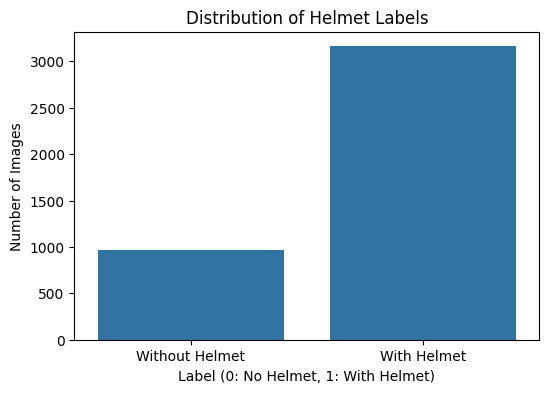

Label 1: 3161 images (76.63%)
Label 0: 964 images (23.37%)


In [ ]:
# Check the distribution of labels
label_counts = labels_df['label'].value_counts()

print("Distribution of labels:")
print(label_counts)

# Visualize the distribution of labels
plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Distribution of Helmet Labels')
plt.xlabel('Label (0: No Helmet, 1: With Helmet)')
plt.ylabel('Number of Images')
plt.xticks(ticks=[0, 1], labels=['Without Helmet', 'With Helmet'])
plt.show()

# Calculate and print percentage of each class
total_images = labels_df.shape[0]
for label, count in label_counts.items():
    percentage = (count / total_images) * 100
    print(f"Label {label}: {count} images ({percentage:.2f}%)")

Now that we have explored the labels, let's extract the image data from the zipped `.npy` files. We will create a new directory for these extracted images.

In [ ]:
import zipfile
import os

extraction_dir = '/content/extracted_images'
os.makedirs(extraction_dir, exist_ok=True)

print(f"Created extraction directory: {extraction_dir}")

# Corrected: Assuming the zip file is within the dataset_folder_path
# dataset_folder_path is defined in a previous cell as '/content/drive/MyDrive/IHelmet Project '
zip_file_path = os.path.join(dataset_folder_path, 'images.npy.zip') # Construct the full path

if os.path.exists(zip_file_path):
    print(f"Extracting '{os.path.basename(zip_file_path)}' to '{extraction_dir}'...")
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extraction_dir)
        print("'.npy.zip' file extracted successfully.")
    except zipfile.BadZipFile:
        print(f"Error: '{zip_file_path}' is a bad zip file.")
    except Exception as e:
        print(f"An error occurred during extraction: {e}")
else:
    print(f"Error: '{zip_file_path}' not found. Please ensure the file exists.")

# Verify extracted files
print(f"\nContents of '{extraction_dir}':")
print(os.listdir(extraction_dir))

Created extraction directory: /content/extracted_images
Extracting 'images.npy.zip' to '/content/extracted_images'...
'.npy.zip' file extracted successfully.

Contents of '/content/extracted_images':
['__MACOSX', 'images.npy']


With the image data extracted, let's load the `images.npy` file and inspect its characteristics, such as shape and data type, to understand its structure.

In [ ]:
import zipfile
import os
import numpy as np

# Ensure extraction directory is created
extraction_dir = '/content/extracted_images'
os.makedirs(extraction_dir, exist_ok=True)

# Construct the full path to the zip file in Google Drive
# dataset_folder_path is defined in a previous cell as '/content/drive/MyDrive/IHelmet Project '
zip_file_path = os.path.join(dataset_folder_path, 'images.npy.zip')

if os.path.exists(zip_file_path):
    print(f"Re-extracting '{os.path.basename(zip_file_path)}' to '{extraction_dir}'...")
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extraction_dir)
        print("'.npy.zip' file re-extracted successfully.")
    except zipfile.BadZipFile:
        print(f"Error: '{zip_file_path}' is a bad zip file.")
    except Exception as e:
        print(f"An error occurred during re-extraction: {e}")
else:
    print(f"Error: '{zip_file_path}' not found. Please ensure the file exists in your Google Drive.")

# Now, load the images.npy file into the 'images' variable
images_file_path = os.path.join(extraction_dir, 'images.npy')
if os.path.exists(images_file_path):
    try:
        images = np.load(images_file_path)
        print("Images loaded successfully into 'images' variable.")
        print(f"Shape of images array: {images.shape}")
    except Exception as e:
        print(f"An error occurred while loading images.npy into 'images' variable: {e}")
        images = None # Set to None if loading fails
else:
    print(f"Error: 'images.npy' not found at {images_file_path} after extraction.")
    images = None # Set to None if not found



Re-extracting 'images.npy.zip' to '/content/extracted_images'...
'.npy.zip' file re-extracted successfully.
Images loaded successfully into 'images' variable.
Shape of images array: (4125, 200, 200, 3)


In [ ]:
import numpy as np
import os # Added os import for os.path.join

images_file_path = os.path.join(extraction_dir, 'images.npy')

if os.path.exists(images_file_path):
    try:
        images = np.load(images_file_path)
        print("Images loaded successfully from 'images.npy'.")
        print(f"Shape of images array: {images.shape}")
        print(f"Data type of images array: {images.dtype}")
    except Exception as e:
        print(f"An error occurred while loading images.npy: {e}")
else:
    print(f"Error: 'images.npy' not found at {images_file_path}")

Images loaded successfully from 'images.npy'.
Shape of images array: (4125, 200, 200, 3)
Data type of images array: uint8


# **Data Preprocessing**

### Splitting the dataset



In [ ]:
# Split the dataset into training and temporary sets (80% train, 20% temp)
X_train, X_temp, y_train, y_temp = train_test_split(images, labels_df['label'], test_size=0.2, random_state=812, stratify=labels_df['label'])

# Split the temporary set into validation and test sets (50% validation, 50% test from temp)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=812, stratify=y_temp)

print(f"Shape of X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}, y_test: {y_test.shape}")

# Display class distribution for each set to confirm stratification
print("\nClass distribution in Training Set:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in Validation Set:")
print(y_val.value_counts(normalize=True))

print("\nClass distribution in Test Set:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (3300, 200, 200, 3), y_train: (3300,)
Shape of X_val: (412, 200, 200, 3), y_val: (412,)
Shape of X_test: (413, 200, 200, 3), y_test: (413,)

Class distribution in Training Set:
label
1    0.766364
0    0.233636
Name: proportion, dtype: float64

Class distribution in Validation Set:
label
1    0.76699
0    0.23301
Name: proportion, dtype: float64

Class distribution in Test Set:
label
1    0.765133
0    0.234867
Name: proportion, dtype: float64


Before we move on to model building, let's visualize some random images from our training set to get a better understanding of the data. We'll display a few images along with their corresponding labels (0 for 'Without Helmet' and 1 for 'With Helmet').

In [ ]:
def plot_random_images(X, y, num_images=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        index = random.randint(0, len(X) - 1)
        image = X[index]
        label = y.iloc[index] # Use iloc for Series

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image)
        plt.title(f"Label: {label} ({'With Helmet' if label == 1 else 'Without Helmet'})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Displaying random images from the training set:")
plot_random_images(X_train_normalized, y_train, num_images=5)

Displaying random images from the training set:


NameError: name 'X_train_normalized' is not defined

To prepare the image data for our neural network model, we need to normalize the pixel values. Currently, the pixel values are in the range of 0-255 (uint8 data type). We will scale these values to a range of 0-1 by dividing by 255.0. This helps the model converge faster and perform better.

In [ ]:
# Normalize the image data to a range of [0, 1]
X_train_normalized = X_train.astype('float32') / 255.0
X_val_normalized = X_val.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

print(f"Original X_train min/max: {X_train.min()}/{X_train.max()}")
print(f"Normalized X_train min/max: {X_train_normalized.min()}/{X_train_normalized.max()}")

print(f"\nOriginal X_val min/max: {X_val.min()}/{X_val.max()}")
print(f"Normalized X_val min/max: {X_val_normalized.min()}/{X_val_normalized.max()}")

print(f"\nOriginal X_test min/max: {X_test.min()}/{X_test.max()}")
print(f"Normalized X_test min/max: {X_test_normalized.min()}/{X_test_normalized.max()}")

Original X_train min/max: 0/255
Normalized X_train min/max: 0.0/1.0

Original X_val min/max: 0/255
Normalized X_val min/max: 0.0/1.0

Original X_test min/max: 0/255
Normalized X_test min/max: 0.0/1.0


### Data Normalization

In [ ]:
# Normalize the image data to a range of [0, 1]
X_train_normalized = X_train.astype('float32') / 255.0
X_val_normalized = X_val.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

print(f"Original X_train min/max: {X_train.min()}/{X_train.max()}")
print(f"Normalized X_train min/max: {X_train_normalized.min()}/{X_train_normalized.max()}")

print(f"\nOriginal X_val min/max: {X_val.min()}/{X_val.max()}")
print(f"Normalized X_val min/max: {X_val_normalized.min()}/{X_val_normalized.max()}")

print(f"\nOriginal X_test min/max: {X_test.min()}/{X_test.max()}")
print(f"Normalized X_test min/max: {X_test_normalized.min()}/{X_test_normalized.max()}")

Original X_train min/max: 0/255
Normalized X_train min/max: 0.0/1.0

Original X_val min/max: 0/255
Normalized X_val min/max: 0.0/1.0

Original X_test min/max: 0/255
Normalized X_test min/max: 0.0/1.0


# **Model Building**

## **Model 1: Convolutional Neural Network (CNN) from Scratch**

We will start by building a simple Convolutional Neural Network (CNN) from scratch. This model will serve as a baseline for helmet detection. The architecture will include convolutional layers, pooling layers, and fully connected layers.

In [ ]:
# Clear any previous model in memory
tf.keras.backend.clear_session()

# Initialize a Sequential model
model = Sequential()

# First Convolutional Block
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(200, 200, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second Convolutional Block
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Third Convolutional Block
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the output from convolutional layers
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=1, activation='sigmoid')) # Output layer for binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,760,641 (33.42 MB)

 Trainable params: 8,760,641 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

### Training the Model

In [ ]:
history = model.fit(
    X_train_normalized, y_train,
    epochs=10, # You can adjust the number of epochs
    batch_size=32,
    validation_data=(X_val_normalized, y_val)
)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.8261 - loss: 0.3965 - val_accuracy: 0.8762 - val_loss: 0.2738
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.9042 - loss: 0.2354 - val_accuracy: 0.8956 - val_loss: 0.2321
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.9224 - loss: 0.1969 - val_accuracy: 0.8981 - val_loss: 0.2184
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.9273 - loss: 0.1816 - val_accuracy: 0.9126 - val_loss: 0.2085
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.9309 - loss: 0.1638 - val_accuracy: 0.8981 - val_loss: 0.2171
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.9333 - loss: 0.1634 - val_accuracy: 0.9053 - val_loss: 0.2323
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.9394 - loss: 0.1551 - val_accuracy: 0.9150 - val_loss: 0.1958
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.9458 - loss: 0.1433 - val_acc

In [ ]:
# Clear any previous model in memory
tf.keras.backend.clear_session()

# Initialize a Sequential model
model = Sequential()

# First Convolutional Block
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(200, 200, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second Convolutional Block
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Third Convolutional Block
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the output from convolutional layers
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=1, activation='sigmoid')) # Output layer for binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,760,641 (33.42 MB)

 Trainable params: 8,760,641 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

### Training the Model

In [1]:
history = model.fit(
    X_train_normalized, y_train,
    epochs=10, # You can adjust the number of epochs
    batch_size=32,
    validation_data=(X_val_normalized, y_val)
)

NameError: name 'model' is not defined

### Model Evaluation

In [ ]:
# Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(X_val_normalized, y_val)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

print("\nClassification Report on Validation Data:")
print(model_performance_classification(model, X_val_normalized, y_val))

print("\nConfusion Matrix on Validation Data:")
plot_confusion_matrix(model, X_val_normalized, y_val)

##Model Evaluation Criterion

## Utility Functions

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='micro')  # to compute Recall
    precision = precision_score(target, pred, average='micro')  # to compute Precision
    f1 = f1_score(target, pred, average='micro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [ ]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

### Visualizing the predictions

## Model 2: Transfer Learning with VGG-16 (Base)

In [2]:
tf.keras.backend.clear_session()

# Load the VGG16 model with pre-trained ImageNet weights, excluding the top (classification) layer
vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3))

# Freeze the layers of the VGG16 base model
for layer in vgg16_base.layers:
    layer.trainable = False

# Create a new model
model_vgg16 = Sequential()

# Add the VGG16 base model
model_vgg16.add(vgg16_base)

# Add custom classification layers
model_vgg16.add(Flatten())
model_vgg16.add(Dense(units=128, activation='relu'))
model_vgg16.add(Dropout(0.5))
model_vgg16.add(Dense(units=1, activation='sigmoid')) # Output layer for binary classification

# Compile the model
model_vgg16.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model_vgg16.summary()

NameError: name 'tf' is not defined

In [ ]:
history_vgg16 = model_vgg16.fit(
    X_train_normalized, y_train,
    epochs=10, # You can adjust the number of epochs
    batch_size=32,
    validation_data=(X_val_normalized, y_val)
)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 19s 156ms/step - accuracy: 0.7736 - loss: 0.4751 - val_accuracy: 0.7670 - val_loss: 0.4257
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.8209 - loss: 0.3575 - val_accuracy: 0.7670 - val_loss: 0.3354
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 153ms/step - accuracy: 0.8442 - loss: 0.3237 - val_accuracy: 0.7743 - val_loss: 0.3632
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 146ms/step - accuracy: 0.8652 - loss: 0.3104 - val_accuracy: 0.8010 - val_loss: 0.3436
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 144ms/step - accuracy: 0.8758 - loss: 0.2792 - val_accuracy: 0.8131 - val_loss: 0.3429
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 140ms/step - accuracy: 0.8915 - loss: 0.2652 - val_accuracy: 0.8665 - val_loss: 0.2686
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 146ms/step - accuracy: 0.8897 - loss: 0.2560 - val_accuracy: 0.8811 - val_loss: 0.2613
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.9024 - loss: 0

### Visualizing the predictions

## Model 3: Transfer Learning with VGG-16 (Base + FFNN)





#### Visualizing the predictions

## Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

#### Visualizing the predictions

# **Model Performance Comparison and Final Model Selection**

## Test Performance

# **Actionable Insights & Recommendations**

-
-

<font size=5 color='blue'>Power Ahead!</font>
___